In [1]:
# AI Anomaly Detection - Supply Chain
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load data
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

# Calculate delivery delay
df['delivery_delay'] = (
    df['Days for shipping (real)'] - 
    df['Days for shipment (scheduled)']
)

print("Data loaded!")
print("Total orders:", len(df))

Data loaded!
Total orders: 180519


In [2]:
# Select columns for anomaly detection
anomaly_df = df[[
    'delivery_delay',
    'Order Item Quantity',
    'Order Item Profit Ratio',
    'Order Item Discount Rate'
]].dropna()

# Build AI Anomaly Detection model
print("Training AI Anomaly Detection model...")
anomaly_model = IsolationForest(
    contamination=0.05,
    random_state=42
)
anomaly_model.fit(anomaly_df)

# Detect anomalies
anomaly_df = anomaly_df.copy()
anomaly_df['anomaly'] = anomaly_model.predict(anomaly_df)

# -1 means anomaly, 1 means normal
anomaly_df['anomaly_label'] = anomaly_df['anomaly'].map({
    1: 'Normal', 
    -1: '🚨 ANOMALY'
})

# Count results
print("\n✅ Anomaly Detection Complete!")
print(anomaly_df['anomaly_label'].value_counts())
print(f"\nTotal anomalies found: {(anomaly_df['anomaly']==-1).sum()}")


Training AI Anomaly Detection model...

✅ Anomaly Detection Complete!
anomaly_label
Normal       171495
🚨 ANOMALY      9024
Name: count, dtype: int64

Total anomalies found: 9024


C:\Users\chand\AppData\Local\Temp\ipykernel_3260\1260055076.py:25: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


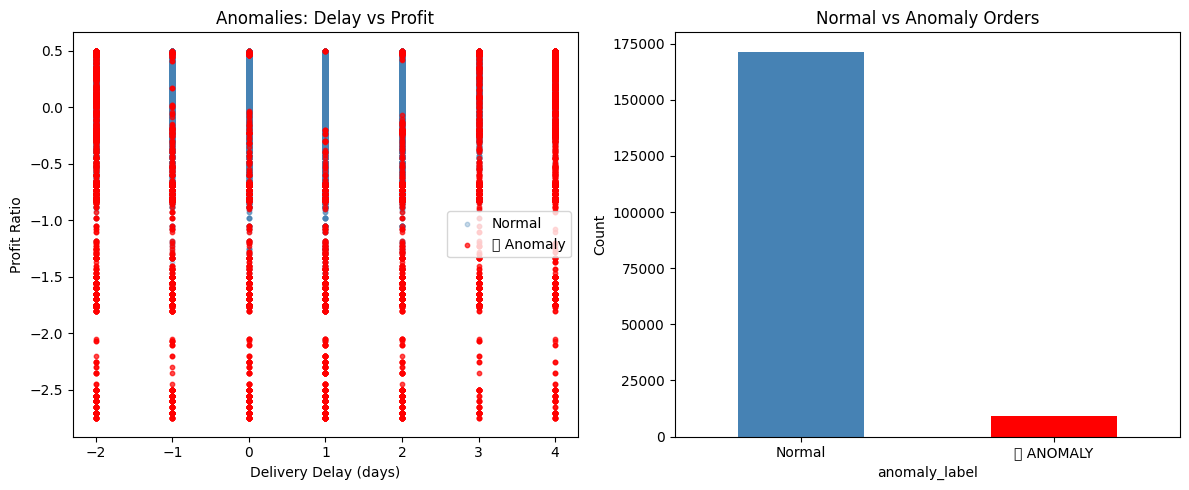

In [3]:
# Visualize anomalies
plt.figure(figsize=(12, 5))

# Plot 1: Anomalies in delivery delay vs profit
plt.subplot(1, 2, 1)
normal = anomaly_df[anomaly_df['anomaly'] == 1]
anomalies = anomaly_df[anomaly_df['anomaly'] == -1]

plt.scatter(normal['delivery_delay'], normal['Order Item Profit Ratio'], 
            alpha=0.3, label='Normal', color='steelblue', s=10)
plt.scatter(anomalies['delivery_delay'], anomalies['Order Item Profit Ratio'], 
            alpha=0.7, label='🚨 Anomaly', color='red', s=10)
plt.xlabel('Delivery Delay (days)')
plt.ylabel('Profit Ratio')
plt.title('Anomalies: Delay vs Profit')
plt.legend()

# Plot 2: Anomaly count
plt.subplot(1, 2, 2)
anomaly_df['anomaly_label'].value_counts().plot(kind='bar', color=['steelblue', 'red'])
plt.title('Normal vs Anomaly Orders')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()